# [LAB-10] 로지스틱 회귀ㅣ06-[PBT] Apple Quality(2).pdf

# 가정 확인 

## # 단계5. 기준선 모형 

### 전처리를 하나도 적용하지 않은 상태에서 먼저 적합한다. 

### 이전 작업 과정 로드 
### 새로운 파일에서 코드 작성시 기존 파일과 흐름이 이어지도록 구성 

In [1]:
import os
print(os.getcwd())

c:\py_temp\15_LAB\[LAB-10] 로지스틱회귀


In [2]:
%%capture cap 
%run "./[LAB-10] 로지스틱 회귀ㅣ06-[PBT] Apple Quality yeonju.ipynb"

## #08. 로지스틱 회귀 기준선 모형 
### 1. 종속변수 라벨링 

로지스틱 회귀의 종속변수는 0/1의 정수여야 하므로 문자열 good/bad를 숫자로 바꾼다.
my_prep.labeling()은 알파벳 순서로 0부터 메긴다. \
bad=0, good=1\

즉 이 모형이 예측하는 것은 P(Quality=good)이고,\
뒤에 나오는 오즈비는 모두 "사과가 'good'일 오즈"에 대한 값이다. 

In [3]:
base = my_prep.labeling(df, columns=[target])
base.head()

Quality (1종) : bad=0
Quality (2종) : bad=0, good=1


,Size,Weight,Sweetness,Crunchiness,Juiciness,Ripeness,Acidity,Quality
0,-3.970,-2.512,5.346,-1.012,1.845,0.330,-0.492,1
1,-1.195,-2.839,3.664,1.588,0.853,0.868,-0.723,1
2,-0.292,-1.351,-1.738,-0.343,2.839,-0.038,2.622,0
3,-0.657,-2.272,1.325,-0.098,3.638,-3.414,0.791,1
4,1.364,-1.297,-0.385,-0.553,3.031,-1.304,0.502,1


### 2. 기준선 모형 적합

In [4]:
fit_base = my_logit.fit_model(base, y=target)
my_logit.report_variables(fit_base, base)

,종속변수,독립변수,B,베타std,표준오차,z,유의확률,오즈비(OR),OR 95% 하한,OR 95% 상한,공차,VIF
0,Quality,Size,0.649,1.252,0.028,22.993,0.000,1.915,1.811,2.024,0.708,1.413
1,Quality,Sweetness,0.569,1.105,0.027,20.938,0.000,1.766,1.675,1.863,0.677,1.477
2,Quality,Juiciness,0.442,0.854,0.024,18.242,0.000,1.556,1.484,1.632,0.820,1.219
3,Quality,Acidity,-0.294,-0.621,0.021,-13.697,0.000,0.745,0.714,0.777,0.853,1.172
4,Quality,Weight,0.267,0.427,0.028,9.399,0.000,1.306,1.235,1.380,0.742,1.348
5,Quality,Ripeness,-0.127,-0.238,0.025,-5.132,0.000,0.881,0.839,0.925,0.677,1.478
6,Quality,Crunchiness,0.035,0.049,0.030,1.143,0.253,1.035,0.976,1.098,0.821,1.218


인사이트 : EDA에서 탈락했던 변수가 되살아났다. 

T검정에서 "차이가 전혀없다"고 나왔던 Acidity와 Weight가 p<0.001로 강하게 유의해졌다. \
이것이 억제효과 suppression이다.\
다른 변수를 통제하지 않은 단독 비교에서 효과가 가려져 있었던 것이다. 

Acidity의 오즈비는 0.745로, 산도가 1점 높아지면 good일 오즈가 약 25.5% 감소한다.

EDA에서 유의하지 않다는 이유만으로 변수를 버리면 안된다.
유의하지 않ㅇ느 변수는 Crunchiness 하나 뿐이지만, 여기서도 아직 지우지 않는다. 

## #6단계. 가정 검정 루프 
### 로지스틱 회귀에서 점검하는 가정은 로짓 선형성과 독립성 두가지 
선형회귀의 정규성, 등분산성 항목은 대상이 아니다.\
이 파이프라인의 핵심 - 가정 검정은 한번으로 끝나지 않고 루프를 돈다. 

진단 - 처방 - 검증 - 재진단 

검증단계를 두는 이유 \
모수를 추가하면 적합도는 언제나 좋아진다 - 개선이 우연 이상인지 확인한 뒤에야 처방을 확정한다. 

재진단을 손대지 않은 변수만 하는 이유\
한 변수를 고치면 다른 변수의 진단 결과가 바뀐다. 그래서 재진단이 필요하다.
이때 처방을 마친 변수는 진단 대상에서 완전히 제외한다 - 파생항을 다시 검정하면 판정이 성립하지 않기 때문이다. 

둘 다 검증을 통과하면 AIC가 낮은 쪽을 채택한다.\
제곱항은 단조 곡선도 근사하므로, "제곱항이 유의하지 않을때만 로그"로 두면 로그가 맞는 형태여도 제곱항이 먼저 뽑힌다. 제곱항이 기각되면 자연히 로그가 채택된다. 

## #6단계. 루프 코딩 주의점 

원본을 그대로 제곱하지 않는다.\
처방 기준값을 반드시 보관한다.\
로그변환은 x>0 일때만 시도한다.\

처방 결과가 다음 단계의 입력이 된다. 
단계 6에서 만든 중심화, 제곱항과 보관한 평균값은 단계7 파이프라인 함수의 로짓 선형성 처방 옵션으로 그대로 들어간다.

즉 단계 6은 진단만 하는 자리가 아니라, 단계 7이 쓸 파생변수를 만들어 넘기는 자리다.

## #09. 가정 점검 

### 1. 기준선 모형의 로짓 선형성 검정 (Box-Tidwell)
독립변수 x에 x 곱하기 ln(x) 항을 추가해 그 항이 유의한지 본다.
유의하면 (p<0.05) 로짓이 직선이 아니라는 뜻 -> 변환, 제곱항, 구간화가 필요하다. 

In [5]:
my_logit.test_linear(fit_base, base)

,z,p-value,linearity,위치이동,result
독립변수,,,,,
Size,4.323,0.000,False,True,대립가설 채택 -> 로짓 선형성 위배(변환 필요)
Weight,11.161,0.000,False,True,대립가설 채택 -> 로짓 선형성 위배(변환 필요)
Sweetness,0.605,0.545,True,True,귀무가설 채택 -> 로짓 선형성 위배 근거 없음
Crunchiness,9.851,0.000,False,True,대립가설 채택 -> 로짓 선형성 위배(변환 필요)
Juiciness,-8.075,0.000,False,True,대립가설 채택 -> 로짓 선형성 위배(변환 필요)
Ripeness,-1.047,0.295,True,True,귀무가설 채택 -> 로짓 선형성 위배 근거 없음
Acidity,-5.553,0.000,False,True,대립가설 채택 -> 로짓 선형성 위배(변환 필요)


결과 \
7종 중 5종이 위배다. \
z값: 위배가 가장 심한 Weight부터 처방한다. 

이 변수들은 음수를 포함하므로 ln의 정의역을 맞추기 위해 최솟값이 1이 되도록 평행이동한 뒤 검정된다.(위치이동 = True)

## #2. 진단 -> 처방 -> 검증 -> 재진단 루프 

In [6]:
fit_fixed = my_logit.fix_linear(base, y=target)

[라운드 1] 위배 5 종 -> 'Weight' 처방 (z=11.1613)
 -> 제곱항 채택 (제곱항 p = 0.0000), 우도비 p = 0.0000e+00, AIC=3962.44
[라운드 2] 위배 5 종 -> 'Crunchiness' 처방 (z=9.0855)
 -> 제곱항 채택 (제곱항 p = 0.0000), 우도비 p = 0.0000e+00, AIC=3867.27
[라운드 3] 위배 3 종 -> 'Juiciness' 처방 (z=-10.5276)
 -> 제곱항 채택 (제곱항 p = 0.0000), 우도비 p = 0.0000e+00, AIC=3744.33
[라운드 4] 위배 3 종 -> 'Acidity' 처방 (z=-7.4836)
 -> 제곱항 채택 (제곱항 p = 0.0000), 우도비 p = 3.2307e-14, AIC=3688.74
[라운드 5] 위배 2 종 -> 'Ripeness' 처방 (z=-3.0869)
 -> 제곱항 채택 (제곱항 p = 0.0023), 우도비 p = 2.1255e-03, AIC=3681.30
[라운드 6] 위배 1 종 -> 'Size' 처방 (z=2.9542)
 -> 제곱항 채택 (제곱항 p = 0.0025), 우도비 p = 2.2468e-03, AIC=3673.97
[라운드 7] 위배 변수 없음 -> 루프 종료



,변수,처방,제곱항 p,검증 p,AIC,채택
라운드,,,,,,
1,Weight,제곱항,0.000,0.000,3962.440,True
2,Crunchiness,제곱항,0.000,0.000,3867.270,True
3,Juiciness,제곱항,0.000,0.000,3744.330,True
4,Acidity,제곱항,0.000,0.000,3688.740,True
5,Ripeness,제곱항,0.002,0.002,3681.300,True
6,Size,제곱항,0.003,0.002,3673.970,True


인사이트 - 하나씩 처방하니 Crunchiness도 해소됐다 

6개 라운드에 결쳐 위배가 심한 변수부터 하나씩 처방되었고, \
7라운드에서 위배 변수가 사라져 루프가 종료됐다.

위배 변수 개수는 줄지만 한번에 하나씩 줄지 않는다.\
한 변수를 고치면 다른 변수의 진단이 함께 바뀌기 때문이다 : 재진단을 반드시 해야 하는 이유

Crunchiness는 T검정 p=0.985(완전무관), 기준선 모형 p=0.253(제거후보)였는데 \
로짓 선형성 진단에서는 두번째로 심한 위배로 잡힌다. 

양 극단이 모두 good쪽이라 평균 비교로는 상쇄되어 보이지 않았을 뿐이다. 

### 4. 관측치의 독립성 - Durbin Watson 

In [7]:
my_logit.test_independent(fit_fixed)

,statistic,independence,result
Durbin-Watson,2.022,True,독립성 만족


결과 \
DW = 2.02로 기준 범위(1.5~2.5)의 한가운데다 -> 독립성 만족\
사과 4,000개는 서로 다른 개체이고, 수집 순서에 의미가 없으므로 설계상으로도 독립이 타당하다 

### 5. 가정 검정 결과 확정
처방 대상 변수 목록을 확정한다. 이 목록이 다음 단계 파이프라인의 옵션이 된다.  

In [8]:
# 확정된 처방 내역 (변수별 처방 방식과 기준값)
recipe = fit_fixed.recipe

for col, rule in recipe.items():
    print(f"{col:14s} : {rule['method']}")

extra_cols = [c for c in continuous_cols if c not in recipe]
print("\n처방 제외 (선형성 충족) : ", extra_cols)
print("미해소 (구간화, 스플라인 필요): ", fit_fixed.unresolved_)

Weight         : square
Crunchiness    : square
Juiciness      : square
Acidity        : square
Ripeness       : square
Size           : square

처방 제외 (선형성 충족) :  ['Sweetness']
미해소 (구간화, 스플라인 필요):  []


In [19]:
base[continuous_cols].min()

Size          -7.152
Weight        -7.150
Sweetness     -6.894
Crunchiness   -6.055
Juiciness     -5.962
Ripeness      -5.865
Acidity       -7.011
dtype: float64

6개 변수(Weight, Crunchiness, Juiciness, Acidity, Ripeness, Size) 전부 method: square(제곱항)로 처방됨 \
      → log가 하나도 없음. 즉 로그변환이 한 번도 채택되지 않았다는 게 여기서 직접 확인됨.\
      
Sweetness는 처방 대상에서 아예 제외(선형성 충족, 위배 안 됨) → 그래서 recipe 딕셔너리에도 안 나옴\

미해소 변수 0개 → 제곱항으로 6종 모두 해소 완료

□ 가정 확인 절차를 수행하고 다음 물음에 답하시오.

21. 종속변수 Quality를 0/1로 라벨링했을 때, good에 부여되는 숫자는 무엇인가요? (정수 1개)

bad = 0, good =1



22. 7개 변수를 모두 넣은 기준선 모형에서, 유의수준 5% 기준으로 유의하지 않은 독립변수는 몇 개인가요? (정수 1개)

Crunchiness 1개 p=0.253

23. 이변량 분석(T검정)에서 유의확률 0.797로 "차이가 없다"고 나왔지만, 기준선 모형에서는 z = -13.70으로 강하게 유의해진 변수는 무엇인가요? (변수명 1개)

Acidity 
p=0.797
z=-13.70
p<0.0001 



24. 문제 23처럼 단독 비교에서는 효과가 가려져 있다가 다른 변수를 통제하자 드러나는 현상을 무엇이라 하나요? (용어 1개)

억제효과



25. 기준선 모형에서 표준화 계수(βstd)가 가장 큰 변수는 무엇인가요? (변수명 1개)

Size,
1.252



26. Box-Tidwell 검정 결과, 7종 중 로짓 선형성을 위배한 변수는 몇 종인가요? (정수 1개)

5개 

`Weight`·`Crunchiness`·`Juiciness`·`Acidity`·`Size` **5종**이 p < 0.05로 위배임.

로지스틱 회귀에서 "선형성"은 종속변수와의 직선관계가 아니라 로짓과의 직선관계임.\
이것이 깨지면 모형이 표현할 수 있는 관계의 모양 자체가 데이터와 맞지 않는다는 뜻임.

27. 위배 정도가 가장 심한(검정통계량 z의 절댓값이 가장 큰) 변수는 무엇인가요? (변수명 1개)

Weight 11.161


`Weight` **z = 11.16**이 가장 크고, `Crunchiness` 9.85, `Juiciness` −8.08, `Acidity` −5.55, `Size` 4.32 순임.

**처방은 위배가 가장 심한 것부터 하나씩 함.** 한꺼번에 고치면 어느 처방이 무엇을 바꿨는지 알 수 없기 때문임.

28. 7종 중 선형성을 충족해 처방 대상에서 제외된 변수는 무엇인가요? (변수명 1개)

Sweetness

`Sweetness`(p = 0.545)와 `Ripeness`(p = 0.295) 둘 다 초기 검정은 통과했지만,\
 **루프를 돌리는 도중 `Ripeness`는 위배로 바뀌어 5라운드에서 처방됨.** 끝까지 원본으로 남은 것은 `Sweetness` 하나임.

**초기 진단 결과가 최종 처방 목록이 아님을 보여주는 대목임.**



29. Weight를 처방한 다음 라운드에서 다시 진단했을 때, 위배로 잡힌 변수는 몇 종인가요? (정수 1개)

5

라운드 1도 5종, 라운드 2도 5종임.
하나를 고쳤는데도 숫자가 줄지 않음.

라운드별 위배 개수는 5 -> 5-> 3-> 3-> 2-> 1->0 으로 움직임.
한 변수를 고치면 다른 변수의 진단 결과가 함께 바뀌기 때문이며, 이것이 처방 후 반드시 재진단을 해야 하는 이유. 

### 2. Crunchiness의 역설 — 왜 특별한 인사이트인가

같은 변수 **Crunchiness**에 대해 분석 방법마다 완전히 다른 결과가 나왔다.

| 분석 방법 | 결과 | 해석 |
|:---|:---:|:---|
| T검정 (단독, 이변량) | p = 0.985 | good/bad 그룹 간 평균 차이 없음 → **완전 무관** |
| 기준선 로지스틱 모형 (7변수 전체 투입) | p = 0.253 | 여전히 유의하지 않음 → **제거 후보** |
| Box-Tidwell 선형성 검정 | z = 9.0855 | 로짓과의 관계가 **직선이 아님** (2번째로 심한 위배) |

### 무슨 일이 일어난 걸까

Crunchiness가 **양 극단(너무 무르거나 너무 단단하거나)일 때 모두 bad**, **중간일 때 good**인 U자형(또는 역U자형) 관계였던 것.

- **T검정**: 평균 비교이므로 왼쪽 극단과 오른쪽 극단이 서로 **상쇄** → "차이 없음"(p=0.985)
- **로지스틱 회귀 1차항**: 직선 기울기만 보므로 마찬가지로 상쇄 → 유의하지 않음(p=0.253)
- **Box-Tidwell**: "직선으로 잘 맞는지" 자체를 검정 → 곡률(U자 구조)을 정확히 포착 (z=9.0855, 강한 위배)

2라운드에서 Crunchiness에 제곱항을 추가하자 그 제곱항이 매우 유의하게 나왔다(p=0.000).

30. 루프가 종료되기까지 실제로 처방이 이루어진 라운드는 몇 번인가요? (정수 1개)

6 라운드

`Weight` → `Crunchiness` → `Juiciness` → `Acidity` → `Ripeness` → `Size` 순으로 **6개 라운드**에서 처방됐고, **7라운드에서 위배 변수가 사라져 종료**됨.

처방 순서도 눈여겨볼 만함. `Crunchiness`는 T검정 p = 0.985(완전 무관), 기준선 모형 p = 0.253(제거 후보)이었는데 **선형성 진단에서는 두 번째로 심한 위배**로 잡힘.

31. 6종에 공통으로 채택된 처방 방법은 무엇인가요? (영문 1개)

square

6종 모두 제곱항 추가(square)로 처방됨.\
recipe에 method: square와 중심화 기준값이 함께 기록되어, 신규 데이터에도 똑같은 기준으로 재현할 수 있음.

기준값을 다시 계산하면 안됨. \
신규 데이터의 평균으로 중심화하면 학습때와 어긋나 예측이 망가짐. 

왓 32. 제곱항과 함께 후보였던 로그 변환이 이 데이터에서는 한 번도 시도되지 않았습니다. 7종 모두가 포함하고 있어 로그를 쓸 수 없게 만든 값은 무엇인가요? (용어 1개)



음수

ln의 정의역은 양수인데 7종 모두 최솟값이 음수임
Size -7.152 
Weight -7.150
Acidity -7.011 

평행이동해서 억지로 쓸 수는 있지만 이동량이 자의적이어서 계수 해석이 무너지므로 기본설정에서는 시도하지 않음 ( allow_shifted_log = False )

> 참고 — 앞서 Box-Tidwell 검정에서 7종 모두 `위치이동 = True`로 표시된 것도 같은 이유임. 검정을 위해 임시로 이동시킨 것이지, 모형에 그 값을 넣은 것은 아님.

recipe 결과(전부 square)는 "로그변환이 결과적으로 안 쓰였다"는 사실만 보여줘
**base[continuous_cols].min()**은 "왜 안 쓰였는지(음수라서 애초에 시도조차 안 됐다)"의 진짜 근거

33. 제곱항으로도 로그 변환으로도 해소되지 않아 구간화·스플라인이 필요하다고 기록된 변수는 몇 개인가요? (정수 1개)

0

unresolved_ 가 빈 목록임. 위배 5종이 전부 제곱항으로 해소됨. 

미해소가 나왔다면 그 변수는 원본 그대로 두고 한계점에 적어야 함.

해소되지 않았는데 억지로 처방하면 근거 없이 모형만 복잡해짐.

34. Durbin-Watson 통계량은 얼마인가요? (소수 셋째 자리)

2.022

기준 범위(1.5 ~ 2.5)의 한가운데라 독립성 만족임.

다만 DW가 정상이라고 독립성이 보장되는 것은 아님.\
사과 4,000개가 서로 다른 개체이고 수집순서에 의미가 없다는 설계상의 근거가 함께 있어야 함. \
같은 나무에서 딴 사과가 섞여 있다면 DW가 정사이어도 독립이 아님. 

왓 35. 제곱항이 모형에 있으면 1차항이 유의하지 않아도 남겨야 한다는 원칙을 무엇이라 하나요? (용어 1개)

계층 원칙 

계층 원칙(hierarchy principle)임. 1차항을 빼면 **곡선의 꼭짓점이 중심값에 고정**되어, 데이터가 말하는 곡선 모양이 왜곡되기 때문임.

**후진소거법과 정면으로 충돌하는 지점임.** 자동 규칙은 유의하지 않은 1차항을 지우려 하지만, 여기서는 통계적 원칙이 앞섬. 실제 판단은 #10의 성능 비교표에서 나란히 놓고 함.

# 분석 파이프 라인 

## # 단계7-1 : 파이프라인 함수 설계

### 전처리 옵션을 함수 하나에 스위치로 모아 둔다( 함수 내부의 실행 순서가 중요)

## # 단계7-2: 체크포인트 비교 설계 

### 전처리를 하나씩 누적한 조합을 정의하고, 반복문으로 일괄 적합한 뒤 비교한다. 

## #10. 로지스틱 회귀 파이프라인 

### 1. 전처리 체크포인트 정의 

전처리 단계를 하나씩 누적한 체크포인트(아래로 갈수록 전처리가 하나 더 붙는다)
0~3번은 가정 검정을 반영하지 않은 조합, 4~7번은 recipe를 적용한 조합이다. 

두 계열의 전처리 조합을 동일하게 맞춰 로짓 선형성 처방의 순수한 효과를 볼 수 있게 한다.

공선성 제거(vif=True)는 모든 체크 포인트에 공통으로 걸어둔다 
앞 과정에서 이미 제거 대상이 없음을 확인했으므로, 별도의 비교 단계로 쪼갤 이유가 없다. 

In [9]:
checkpoints = {
    # --- 가정 검정 미반영 --- 
    "0_기준선" : dict(vif=True),
    "1_후진소거": dict(backward=True, vif=True),
    "2_이상치대체": dict(backward=True, outlier=True, vif=True),
    "3_정규화": dict(backward=True, outlier=True, vif=True, scale=True),

    # --- 가정 검정 반영 (로짓 선형성 처방) ---
    "4_가정반영" : dict(recipe=recipe, vif=True),
    "5_가정반영+후진소거": dict(recipe=recipe, backward=True, vif=True),
    "6_가정반영+이상치대체": dict(recipe=recipe, backward=True, outlier=True, vif=True),
    "7_가정반영+정규화": dict(recipe=recipe, backward=True, outlier=True, vif=True, scale=True)
}

### 2. 모델별 체크 포인트 적합 

In [10]:
fits = {} # 적합된 모델을 누적한 딕셔너리 

for name in checkpoints:
    print(f"\n --- {name} ---")

    fits[name] = my_logit.fit_pipeline(
        base, target, continuous_cols, name=name, **checkpoints[name])

print("\n 누적된 모델: ", len(fits), "개")


 --- 0_기준선 ---

완료! 남은변수 : ['Acidity', 'Crunchiness', 'Juiciness', 'Ripeness', 'Size', 'Sweetness', 'Weight']
최대 VIF = 1.48


 --- 1_후진소거 ---

완료! 남은변수 : ['Acidity', 'Crunchiness', 'Juiciness', 'Ripeness', 'Size', 'Sweetness', 'Weight']
최대 VIF = 1.48

유의하지 않은 독립변수 제거 -> Crunchiness (p=0.2532)

 --- 2_이상치대체 ---

완료! 남은변수 : ['Acidity', 'Crunchiness', 'Juiciness', 'Ripeness', 'Size', 'Sweetness', 'Weight']
최대 VIF = 1.47

유의하지 않은 독립변수 제거 -> Crunchiness (p=0.3016)

 --- 3_정규화 ---

완료! 남은변수 : ['Acidity', 'Crunchiness', 'Juiciness', 'Ripeness', 'Size', 'Sweetness', 'Weight']
최대 VIF = 1.47

유의하지 않은 독립변수 제거 -> Crunchiness (p=0.3016)

 --- 4_가정반영 ---

완료! 남은변수 : ['Acidity_c', 'Acidity_c2', 'Crunchiness_c', 'Crunchiness_c2', 'Juiciness_c', 'Juiciness_c2', 'Ripeness_c', 'Ripeness_c2', 'Size_c', 'Size_c2', 'Sweetness', 'Weight_c', 'Weight_c2']
최대 VIF = 1.61


 --- 5_가정반영+후진소거 ---

완료! 남은변수 : ['Acidity_c', 'Acidity_c2', 'Crunchiness_c', 'Crunchiness_c2', 'Juiciness_c', 'Juiciness_c2', 'Ripeness_c',

### 전체 모델 성능 비교
성능을 바꾼 것은 전처리가 아니라 가정 검정이었다. 

In [11]:
best = my_logit.compare_models(fits)
print("간명성 기준 1순위: ", best.name_)

,변수수,정확도,정밀도,재현율,F1,AUC,Pseudo R^2,AIC,Gap(%)
모델,,,,,,,,,
5_가정반영+후진소거,12,0.791,0.784,0.804,0.794,0.868,0.343,3672.041,0.000
6_가정반영+이상치대체,12,0.793,0.787,0.805,0.796,0.868,0.341,3677.811,0.060
7_가정반영+정규화,12,0.793,0.787,0.805,0.796,0.868,0.341,3677.811,0.060
4_가정반영,13,0.792,0.785,0.804,0.795,0.868,0.343,3673.968,0.000
0_기준선,7,0.749,0.741,0.766,0.753,0.824,0.258,4129.557,5.080
1_후진소거,6,0.750,0.742,0.767,0.754,0.824,0.258,4128.863,5.090
2_이상치대체,6,0.749,0.741,0.766,0.754,0.823,0.257,4136.292,5.170
3_정규화,6,0.749,0.741,0.766,0.754,0.823,0.257,4136.292,5.170


간명성 기준 1순위:  5_가정반영+후진소거


In [12]:
# Gap(%) 성능차이가 5% 이상이므로 고려대상 아님 

### 4. 최종 모델 선택 

my_logit.compare_models()는 근소 격차 그룹 안에서 변수가 하나 적은 '5_가정반영+후진소거'를 1순위로 지목한다.\
하지만 5번이 지운 변수는 제곱항의 짝인 Crunchiness_c이므로 4번을 채택한다.\
AIC 차이는 1.93(3673.97 -> 3672.04)에 불과해, 변수 하나를 지워 얻는 이득이 거의 없다.\
간명성 규칙이 통계적 원칙보다 앞설 수는 없다.\
자동 선택 결과는 언제나 분석자가 검토해야 한다.

In [13]:
# 계층 원칙에 따라 4번을 최종 채택 한다.
final_name = "4_가정반영"

final_fit = fits[final_name]    
final_data = final_fit.data_ # 전처리가 끝난 데이터 (보고에 사용)

print("최종모델 : ", final_name)
print("독립변수: ", int(final_fit.df_model), "개")

최종모델 :  4_가정반영
독립변수:  13 개


□ 분석 결과를 확인하고 다음 물음에 답하시오.

36. 성능 비교를 위해 정의한 전처리 체크포인트는 모두 몇 개인가요? (정수 1개)

8

가정 검정 미반영 4개(0 ~ 3번) + 가정 검정 반영 4개(4 ~ 7번) = **8개**임.

**두 계열의 전처리 조합을 똑같이 맞춘 것이 핵심임.** 그래야 다른 조건이 같은 상태에서 **로짓 선형성 처방만의 순수한 효과**를 읽을 수 있음.




37. 8개 체크포인트 전부에 공통으로 적용된 전처리 옵션은 무엇인가요? (옵션명 1개)

공선성 제거(vif=True)
앞 과정에서 이미 제거대상이 없음을 확인했으므로, 별도의 비교 단계로 쪼갤 이유가 없다

공선성 제거(`vif=True`)는 비교 대상에서 뺀 것이 아니라 **모든 체크포인트에 공통으로** 걸어 둔 것임. #06에서 이미 강한 상관 조합이 0개임을 확인했으므로 단계로 쪼갤 이유가 없기 때문임.

**실제로 제거된 변수도 없음.** 최대 VIF가 미반영 계열 1.48, 반영 계열 1.61로 기준(보통 10)에 한참 못 미침.



38. 가정 검정을 반영한 계열에서 후진소거법이 제거한 변수는 무엇인가요? (변수명 1개)
Crunchiness_c



39. 정규화를 적용한 3번과 적용하지 않은 2번을 비교하면, 성능 지표 중 값이 달라지는 것은 몇 개인가요? (정수 1개)

없음

정확도·정밀도·재현율·F1·AUC·Pseudo R²·AIC가 **전부 동일**함(0.749 / 0.741 / 0.766 / 0.754 / 0.823 / 0.257 / 4136.292). 반영 계열의 6번과 7번도 마찬가지임.

**정규화는 계수의 척도만 바꿀 뿐 모형 자체를 바꾸지 않기 때문임.** 로지스틱 회귀에서 스케일링은 성능 향상 수단이 아니라 **계수 비교를 편하게 하는 도구**임.




40. AIC가 가장 낮은(가장 좋은) 모델의 이름은 무엇인가요? (모델명 1개)

5_가정반영+후진소거

AIC **3672.041**로 최소임. 그다음이 `4_가정반영` 3673.968임.

**AUC 0.824 → 0.868, AIC 4128.9 → 3672.0.** 이상치 대체·공선성 제거·정규화를 전부 합친 것보다 **로짓 선형성 처방 하나가 압도적으로 큰 개선**을 만들었음. 기계적 전처리는 잡음을 다듬는 일이지만, 제곱항 추가는 **모형이 표현할 수 있는 관계의 모양 자체를 바꾸는 일**이기 때문임.



왓 41. compare_models()가 1순위로 지목한 모델을 그대로 쓰지 않고, 실제로 최종 채택한 모델은 무엇인가요? (모델명 1개)

4_가정반영 

자동 선택은 근소 격차 그룹 안에서 변수가 하나 적은 `5_가정반영+후진소거`를 1순위로 지목함. 하지만 5번이 지운 변수가 제곱항의 짝인 `Crunchiness_c`이므로, **계층 원칙에 따라 4번을 채택**함.

**간명성 규칙이 통계적 원칙보다 앞설 수는 없음.** 자동 선택 결과는 언제나 분석자가 검토해야 함.

5번은 AUC·AIC가 제일 좋아 보이지만, 그 이유가 제곱항(Crunchiness_c2)은 남겨두고 짝인 1차항(Crunchiness_c)만 지운 것이라 통계적으로 반칙(위계 원칙 위반)이야. 그래서 점수는 낮아도 원칙을 지킨 4번을 최종 채택한 거야.

어떻게 알았냐면:

compare_models 표만 보면 5번이 1등 (변수 적고 AIC 낮음)
근데 로그를 보니 5번이 지운 게 Crunchiness_c2(제곱항)가 아니라 Crunchiness_c(1차항)
x²는 남기고 x만 빼면 안 됨 → 규칙 위반
그래서 점수표는 무시하고 4번(1차항·제곱항 다 온전한 모델)을 선택



In [ ]:
# ## 배경 — compare_models가 하는 일

# `compare_models(fits)`는 여러 모델을 성능 지표로 줄 세우는 함수야. 기본 설정은:
# - 주 지표: `AUC`
# - 근소 격차 기준: `tolerance=0.05` (5%)
# - 보조 지표: `변수수`

# **로직**: 먼저 AUC로 줄을 세운다. 근데 1등과 AUC 차이가 5% 이내인 모델들은 "사실상 성능이 똑같다"고 보고, 그 안에서는 **변수 개수가 적은 모델(더 간명한 모델)을 우선**한다.

# ## 1단계 — 표에서 실제로 일어난 일

# ```
# 5_가정반영+후진소거   변수수 12   AUC 0.868   AIC 3672.041   Gap 0.000
# 6_가정반영+이상치대체  변수수 12   AUC 0.868   AIC 3677.811   Gap 0.060
# 7_가정반영+정규화     변수수 12   AUC 0.868   AIC 3677.811   Gap 0.060
# 4_가정반영           변수수 13   AUC 0.868   AIC 3673.968   Gap 0.000
# ```

# 4, 5, 6, 7번 모두 AUC가 0.868로 사실상 동일 → "근소 격차 그룹"에 다 같이 묶임.
# 이 그룹 안에서 변수 개수 비교: 5·6·7번은 12개, 4번은 13개.
# → **변수가 하나 적은 5번이 가장 간명하다고 판단해서 1순위로 뽑힘.**

# 여기까지는 함수가 설계된 대로 정상 작동한 거야. 잘못된 게 아니야.

# ## 2단계 — "그런데 12개로 어떻게 줄인 거지?" 를 로그에서 확인

# 표만 보면 "5번이 변수 하나 덜 쓰고도 성능이 똑같네, 좋은 모델이네"로 끝날 수 있어. 근데 **그 변수 하나를 어떻게 줄였는지**를 봐야 해. 그게 `fit_pipeline` 실행 로그에 남아있어:

# ```
# --- 4_가정반영 ---
# 남은변수 : [..., 'Crunchiness_c', 'Crunchiness_c2', ...]   ← 13개, 후진소거 없음

# --- 5_가정반영+후진소거 ---
# 남은변수 : [..., 'Crunchiness_c2', ...]                     ← 12개
# 유의하지 않은 독립변수 제거 -> Crunchiness_c (p=0.7869)
# ```

# 4번은 원래 13개 변수를 그대로 다 갖고 있어. 5번은 거기서 후진소거법으로 **`Crunchiness_c` 딱 하나만** 지워서 12개가 된 거야.

# ## 3단계 — 근데 지운 게 하필 "짝 있는 변수의 반쪽"

# 여기서 이름을 잘 봐야 해:
# - `Crunchiness_c` = Crunchiness를 중심화한 **1차항** (원본 변수를 평균 빼서 옮긴 것)
# - `Crunchiness_c2` = 그 중심화된 값을 **제곱한 항** (곡선 효과를 담당)

# 이 둘은 원래 **세트로 같이 들어가야 하는 짝**이야. Apple Quality 실습에서 이미 배운 원칙:

# > **제곱항(x²)이 모형에 남아있으면, 그 1차항(x)이 통계적으로 유의하지 않더라도 절대 빼면 안 된다.**

# 왜냐면 — `x`와 `x²`를 같이 넣는다는 건 "이 변수는 직선이 아니라 곡선(포물선) 관계를 가진다"고 모형에게 알려주는 거야. `x²`만 남기고 `x`를 빼버리면, 그 곡선의 기준점(꼭짓점 위치)이 원래 의도했던 x=0(=변수의 평균값)이 아니라 임의의 지점으로 뒤틀려버려. 그러면 계수를 봐도 "이게 무슨 의미인지" 해석이 깨져버려.

# 즉 5번이 한 일은: **곡선 모양(제곱항)은 유지하면서, 그 곡선이 어디를 중심으로 도는지 알려주는 정보(1차항)만 빼버린 것**. 통계적으로 이건 "간명하게 줄인 것"이 아니라 "모형을 망가뜨린 것"에 가까워.

# ## 4단계 — 근데 왜 점수는 좋게 나왔을까

# 후진소거법은 오직 **"이 변수의 p-value가 유의수준보다 큰가"** 만 보고 지울지 말지 결정해. `Crunchiness_c`의 p값이 0.7869로 컸으니까 기계적으로 지운 거고, 우연히도 그 결과 AIC가 살짝 더 낮아지고 변수 개수도 줄어서 `compare_models` 지표상으로는 "더 좋은 모델"처럼 보인 거야.

# **핵심은 이거야: `compare_models`도, 후진소거법도 "위계 원칙(hierarchy principle)을 지켰는가"는 전혀 검사하지 않아.** 그냥 숫자(AUC, AIC, 변수수, p-value)만 보고 기계적으로 판단해.

# ## 5단계 — 그래서 최종 결론

# - 표만 보면: 5번이 1등
# - 로그까지 보면: 5번은 통계적으로 하면 안 되는 짓(짝 있는 변수 중 1차항만 제거)을 해서 얻은 점수
# - 그래서 사람이 개입해서: **위계 원칙을 지킨 4번(1차항·제곱항 둘 다 온전히 보유)을 최종 채택**

# ## 이 사례가 말해주는 것

# 자동화된 지표(compare_models 순위)를 그대로 믿지 말고, **그 순위가 나온 과정(로그)을 반드시 열어봐야 한다**는 거야. 숫자상 1등이라고 무조건 쓰면, 이번처럼 통계적으로 잘못된 모형을 최종 모델로 채택하는 실수를 할 수 있어. "간명성(변수 적음)"이라는 실용적 기준은, "위계 원칙을 지키는가" 같은 통계적 원칙보다 절대 우선할 수 없다는 게 이 문제의 교훈이야.

42. 두 모델의 AIC 차이는 얼마인가요? (소수 둘째 자리)

1.93 

3673.968 − 3672.041 = **1.93**임.

**이 숫자가 판단의 근거임.** 변수 하나를 지워 얻는 AIC 이득이 2도 안 되는데, 그 대가로 계층 원칙을 깨야 한다면 남기는 쪽이 맞음. "원칙이니까 남긴다"가 아니라 **"이득이 이만큼 작으니 남긴다"** 로 말해야 보고서가 됨.

# 결과 보고 

## #11. 최종 채택 모델에 대한 결과 보고 

### 1. 모형 적합도 

In [14]:
Markdown(my_logit.report_fitness(final_fit))    

**Note. n=4000.LL = -1822.984, LL-Null = -2772.581, LLR x^2 (13) = 1899.193, p < 0.001, Pseudo R^2 = 0.342**

Quality를 종속변수로, Sweetness, Weight_c, Weight_c2, Crunchiness_c, Crunchiness_c2, Juiciness_c, Juiciness_c2, Acidity_c, Acidity_c2, Ripeness_c, Ripeness_c2, Size_c, Size_c2(을)를 독립변수로 한 이항 로지스틱 회귀분석 결과, 모형은 통계적으로 유의하였다.

> LLR x^2 (13)=1899.193, p < 0.001, Pseudo R^2 = 0.342.

즉, 모형의 유사결정계수는 0.342로 매우 우수한적합 수준을 보였다.

> Pseudo R^2는 선형회귀의 R^2처럼 '분산 설명 비율'로 해석하지 않는다. 일반적으로 **0.2~0.4** 구간이면 매우 우수한 적합으로 본다

### 2. 독립변수 보고 

In [15]:
display(my_logit.report_variables(final_fit, final_data))
Markdown(my_logit.report_variables_text(final_fit, data=final_data))

,종속변수,독립변수,B,베타std,표준오차,z,유의확률,오즈비(OR),OR 95% 하한,OR 95% 상한,공차,VIF
0,Quality,Size_c,0.629,1.214,0.031,20.410,0.000,1.876,1.766,1.993,0.664,1.506
1,Quality,Sweetness,0.568,1.105,0.030,18.806,0.000,1.766,1.664,1.873,0.646,1.547
2,Quality,Juiciness_c,0.485,0.937,0.027,17.805,0.000,1.625,1.540,1.714,0.787,1.270
3,Quality,Acidity_c,-0.274,-0.578,0.023,-11.889,0.000,0.760,0.727,0.795,0.831,1.203
4,Quality,Crunchiness_c2,0.192,0.625,0.019,10.399,0.000,1.212,1.169,1.257,0.922,1.084
5,Quality,Ripeness_c,-0.184,-0.345,0.029,-6.378,0.000,0.832,0.786,0.880,0.622,1.609
6,Quality,Weight_c2,0.176,0.693,0.015,11.948,0.000,1.192,1.158,1.227,0.951,1.051
7,Quality,Weight_c,0.165,0.264,0.033,4.945,0.000,1.179,1.105,1.259,0.702,1.424
8,Quality,Juiciness_c2,-0.103,-0.547,0.010,-9.991,0.000,0.902,0.884,0.920,0.884,1.131
9,Quality,Acidity_c2,-0.061,-0.375,0.008,-7.590,0.000,0.941,0.926,0.956,0.893,1.120


- **Sweetness**의 회귀계수는 **B = 0.5685**, 오즈비는 **OR=1.7656**로 나타났으며, 이는 **Quality**에 유의한 요인임을 의미한다(**z = 18.81**, **p < .001**)즉, **Sweetness**가 1 증가할때 Quality가 1(사건 발생)이 될 오즈는 평균적으로 약 **76.6% 증가** 하는 것으로 해석된다.
- **Weight_c**의 회귀계수는 **B = 0.165**, 오즈비는 **OR=1.1794**로 나타났으며, 이는 **Quality**에 유의한 요인임을 의미한다(**z = 4.94**, **p < .001**)즉, **Weight_c**가 1 증가할때 Quality가 1(사건 발생)이 될 오즈는 평균적으로 약 **17.9% 증가** 하는 것으로 해석된다.
- **Weight_c2**의 회귀계수는 **B = 0.1758**, 오즈비는 **OR=1.1922**로 나타났으며, 이는 **Quality**에 유의한 요인임을 의미한다(**z = 11.95**, **p < .001**)즉, **Weight_c2**가 1 증가할때 Quality가 1(사건 발생)이 될 오즈는 평균적으로 약 **19.2% 증가** 하는 것으로 해석된다.
- **Crunchiness_c**의 회귀계수는 **B = 0.0097**, 오즈비는 **OR=1.0098**로 나타났으며, 이는 **Quality**에 유의하지 않은 요인임을 의미한다(**z = 0.27**, **p=.787**)즉, **Crunchiness_c**가 1 증가할때 Quality가 1(사건 발생)이 될 오즈는 평균적으로 약 **1.0% 증가** 하는 것으로 해석된다.
- **Crunchiness_c2**의 회귀계수는 **B = 0.1925**, 오즈비는 **OR=1.2122**로 나타났으며, 이는 **Quality**에 유의한 요인임을 의미한다(**z = 10.4**, **p < .001**)즉, **Crunchiness_c2**가 1 증가할때 Quality가 1(사건 발생)이 될 오즈는 평균적으로 약 **21.2% 증가** 하는 것으로 해석된다.
- **Juiciness_c**의 회귀계수는 **B = 0.4853**, 오즈비는 **OR=1.6247**로 나타났으며, 이는 **Quality**에 유의한 요인임을 의미한다(**z = 17.81**, **p < .001**)즉, **Juiciness_c**가 1 증가할때 Quality가 1(사건 발생)이 될 오즈는 평균적으로 약 **62.5% 증가** 하는 것으로 해석된다.
- **Juiciness_c2**의 회귀계수는 **B = -0.1031**, 오즈비는 **OR=0.902**로 나타났으며, 이는 **Quality**에 유의한 요인임을 의미한다(**z = -9.99**, **p < .001**)즉, **Juiciness_c2**가 1 증가할때 Quality가 1(사건 발생)이 될 오즈는 평균적으로 약 **9.8% 감소** 하는 것으로 해석된다.
- **Acidity_c**의 회귀계수는 **B = -0.274**, 오즈비는 **OR=0.7603**로 나타났으며, 이는 **Quality**에 유의한 요인임을 의미한다(**z = -11.89**, **p < .001**)즉, **Acidity_c**가 1 증가할때 Quality가 1(사건 발생)이 될 오즈는 평균적으로 약 **24.0% 감소** 하는 것으로 해석된다.
- **Acidity_c2**의 회귀계수는 **B = -0.061**, 오즈비는 **OR=0.9408**로 나타났으며, 이는 **Quality**에 유의한 요인임을 의미한다(**z = -7.59**, **p < .001**)즉, **Acidity_c2**가 1 증가할때 Quality가 1(사건 발생)이 될 오즈는 평균적으로 약 **5.9% 감소** 하는 것으로 해석된다.
- **Ripeness_c**의 회귀계수는 **B = -0.184**, 오즈비는 **OR=0.8319**로 나타났으며, 이는 **Quality**에 유의한 요인임을 의미한다(**z = -6.38**, **p < .001**)즉, **Ripeness_c**가 1 증가할때 Quality가 1(사건 발생)이 될 오즈는 평균적으로 약 **16.8% 감소** 하는 것으로 해석된다.
- **Ripeness_c2**의 회귀계수는 **B = -0.0309**, 오즈비는 **OR=0.9696**로 나타났으며, 이는 **Quality**에 유의한 요인임을 의미한다(**z = -3.02**, **p=.002**)즉, **Ripeness_c2**가 1 증가할때 Quality가 1(사건 발생)이 될 오즈는 평균적으로 약 **3.0% 감소** 하는 것으로 해석된다.
- **Size_c**의 회귀계수는 **B = 0.6294**, 오즈비는 **OR=1.8765**로 나타났으며, 이는 **Quality**에 유의한 요인임을 의미한다(**z = 20.41**, **p < .001**)즉, **Size_c**가 1 증가할때 Quality가 1(사건 발생)이 될 오즈는 평균적으로 약 **87.6% 증가** 하는 것으로 해석된다.
- **Size_c2**의 회귀계수는 **B = 0.029**, 오즈비는 **OR=1.0294**로 나타났으며, 이는 **Quality**에 유의한 요인임을 의미한다(**z = 3.02**, **p=.003**)즉, **Size_c2**가 1 증가할때 Quality가 1(사건 발생)이 될 오즈는 평균적으로 약 **2.9% 증가** 하는 것으로 해석된다.

> 오즈비(OR)가 1보다 크면 사건 발생 오즈가 증가, 1보다 작으면 감소함을 뜻한다 유의확률이 유의수준보다 큰(=유의하지 않은) 변수는 효과가 통계적으로 확인되지 않았으므로오즈비 해석에 주의한다. 더미변수의 오즈비는 '기준(drop_first로 제외된)범주' 대비 값이다

### 3. 오즈비 시각화 

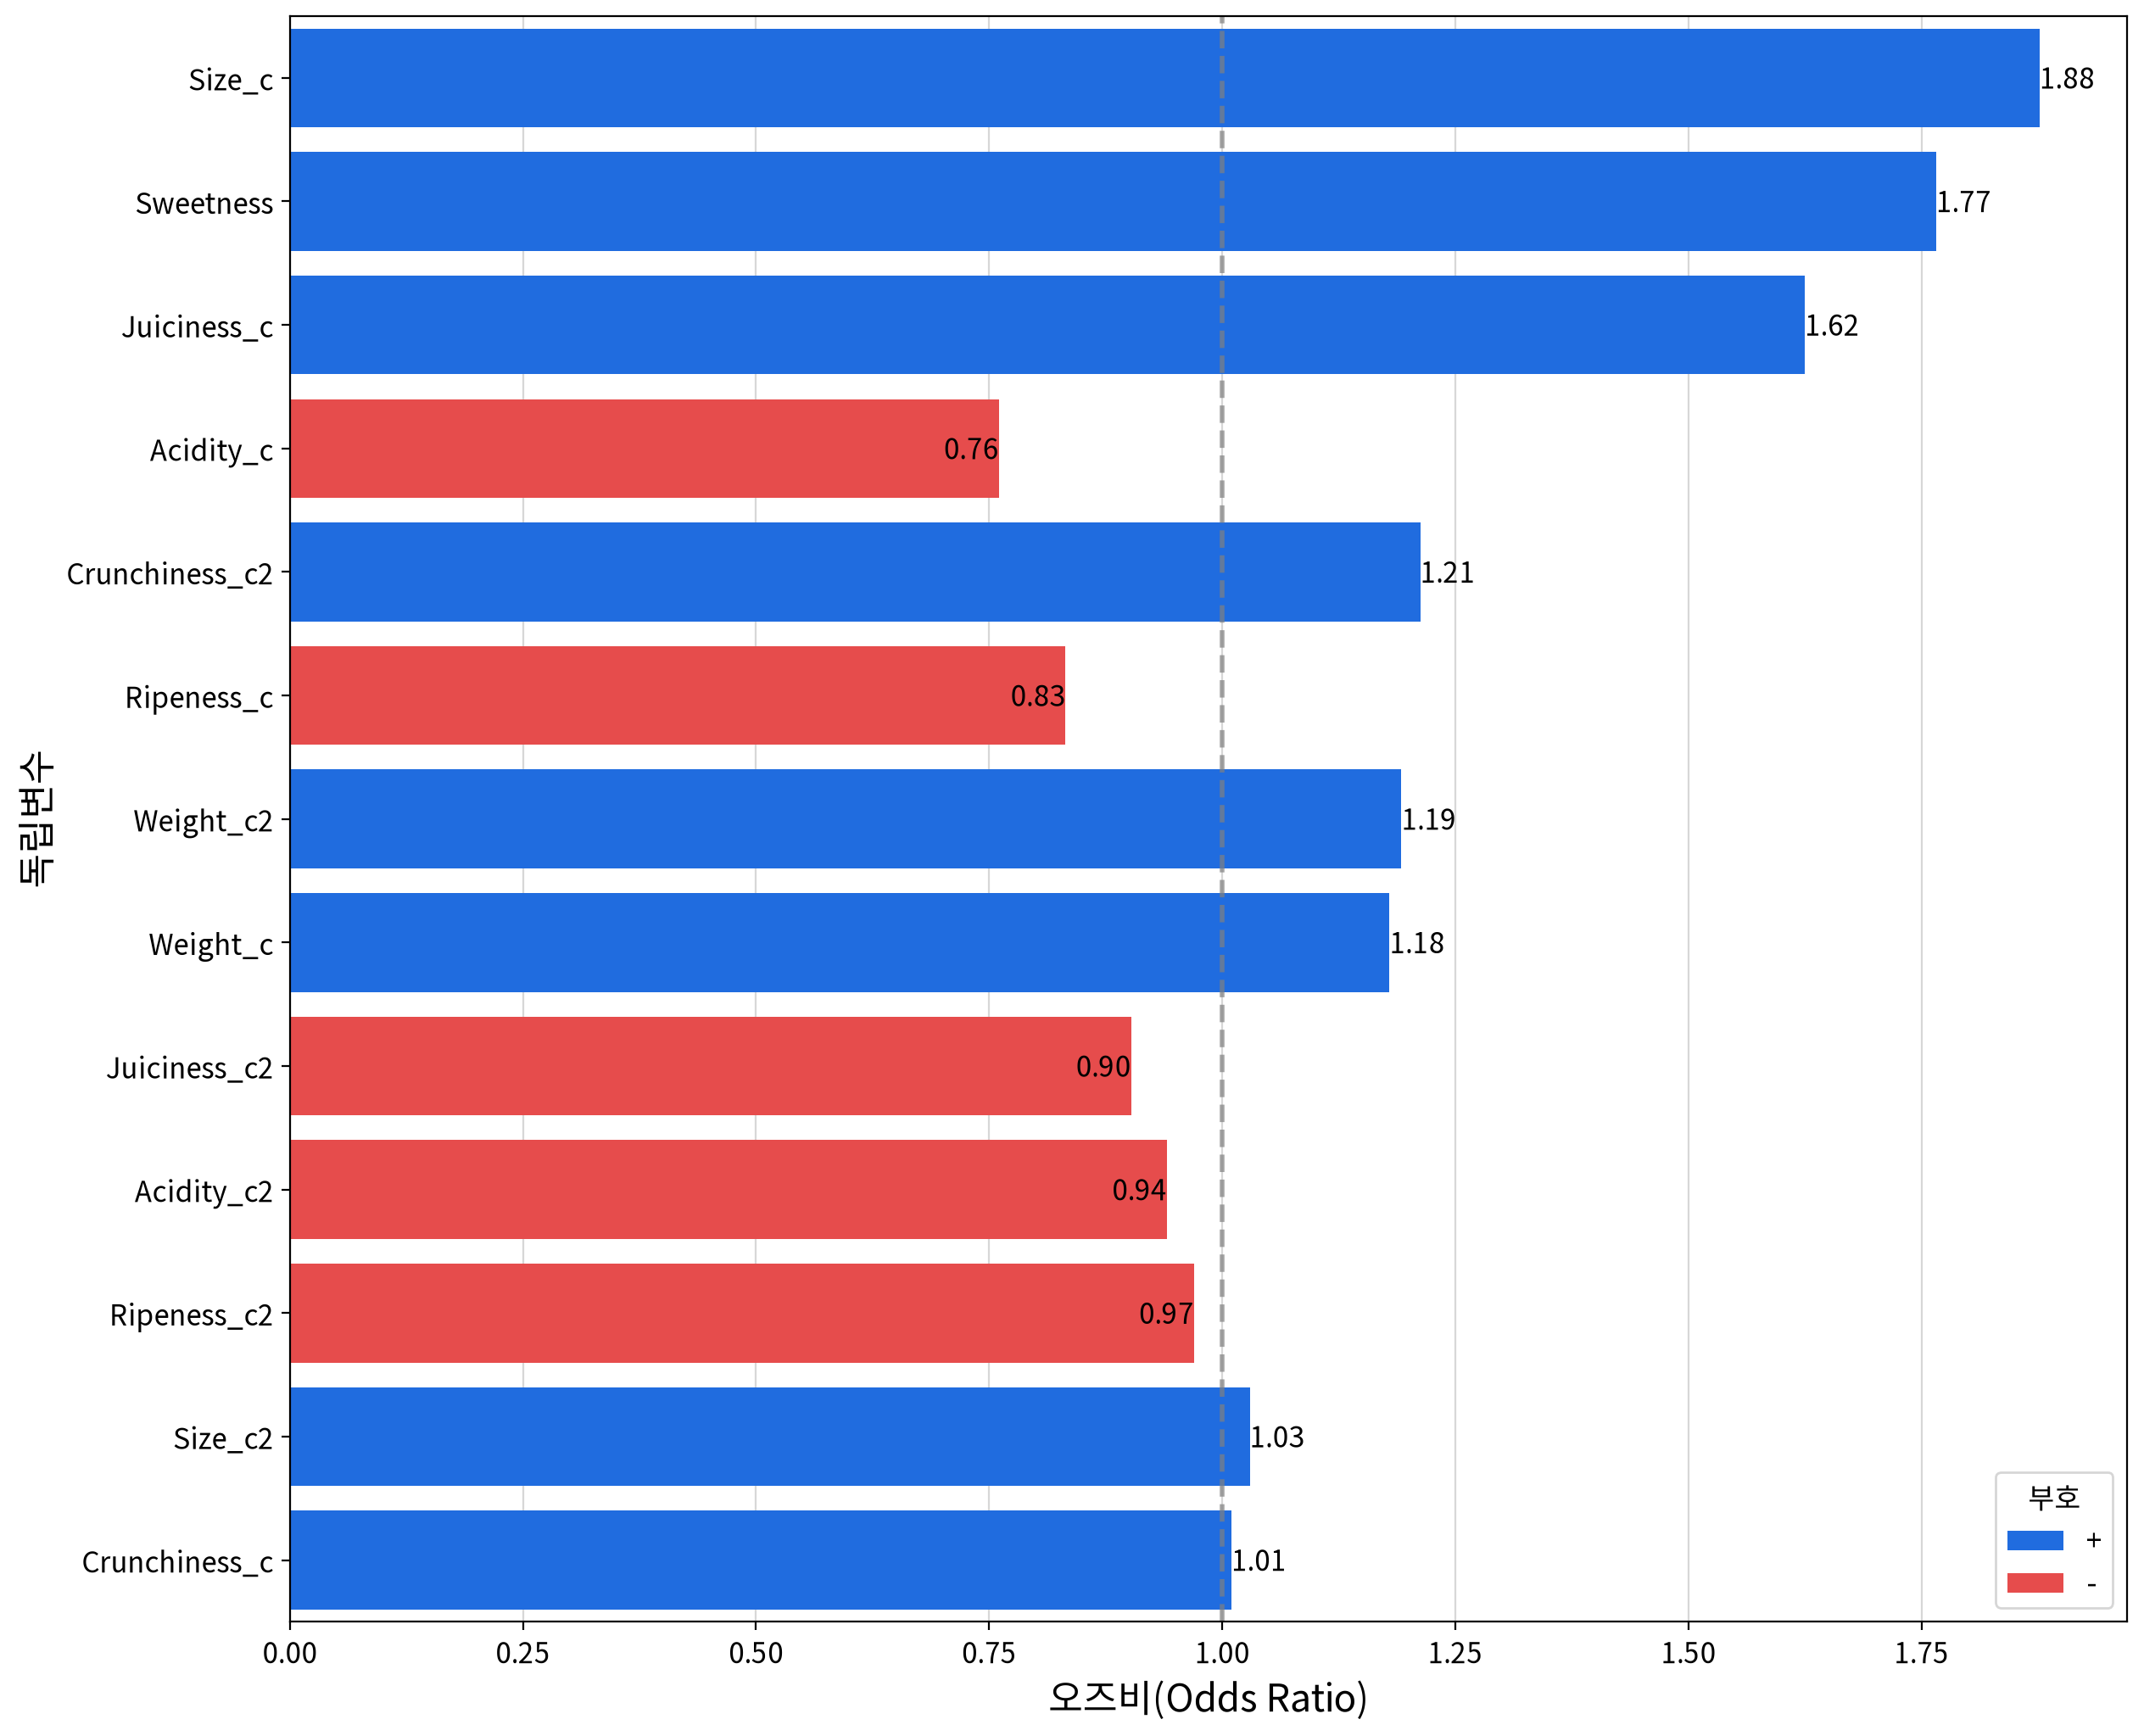

In [16]:
my_logit.plot_odds(final_fit, final_data)

## # 11. 최종 채택 모델에 대한 결과 보고 

인사이트 1) 계수 해석 

LLR X^2(13) = 1,899.19, p<0.001, Pseudo R^2=0.342로 매우 우수한 적합이다.\
13개 항 중 12개가 유의하다? \

영향력 1위는 Size\
표준화 계수 베타std = 1.214\
Sweetness 1.105\
Juiciness 0.937 \

크기, 단맛, 과즙이 품질을 결정하는 3대 축 \

Sweetness 1.766 

단맛 1점 상승시, good일 오즈 76.6% 증가 

제곱항이 있는 변수는 오즈비를 한 줄로 해석하지 않는다. \
1차항과 제곱항 두 계수가 함께 곡선을 만든다 라고 명시해야 함.

인사이트 2) 계수 해석: 곡선 관계 

1차항 + 제곱항이 있는 변수 (곡선 관계) - 두 계숙 함께 곡선을 만든다

### 4. 분류 성능 평가 

,예측 0 (Negative),예측 1 (Positive)
실제 0 (Negative),1555,441
실제 1 (Positive),392,1612


,정확도(Accuracy),정밀도(Precision),"재현율(Recall, TPR)","위양성율(Fallout, FPR)","특이성(Specificity, TNR)",F1,AUC,AUC 판단,진단오즈비(DOR)
preformance,0.792,0.785,0.804,0.221,0.779,0.795,0.868,우수,14.500


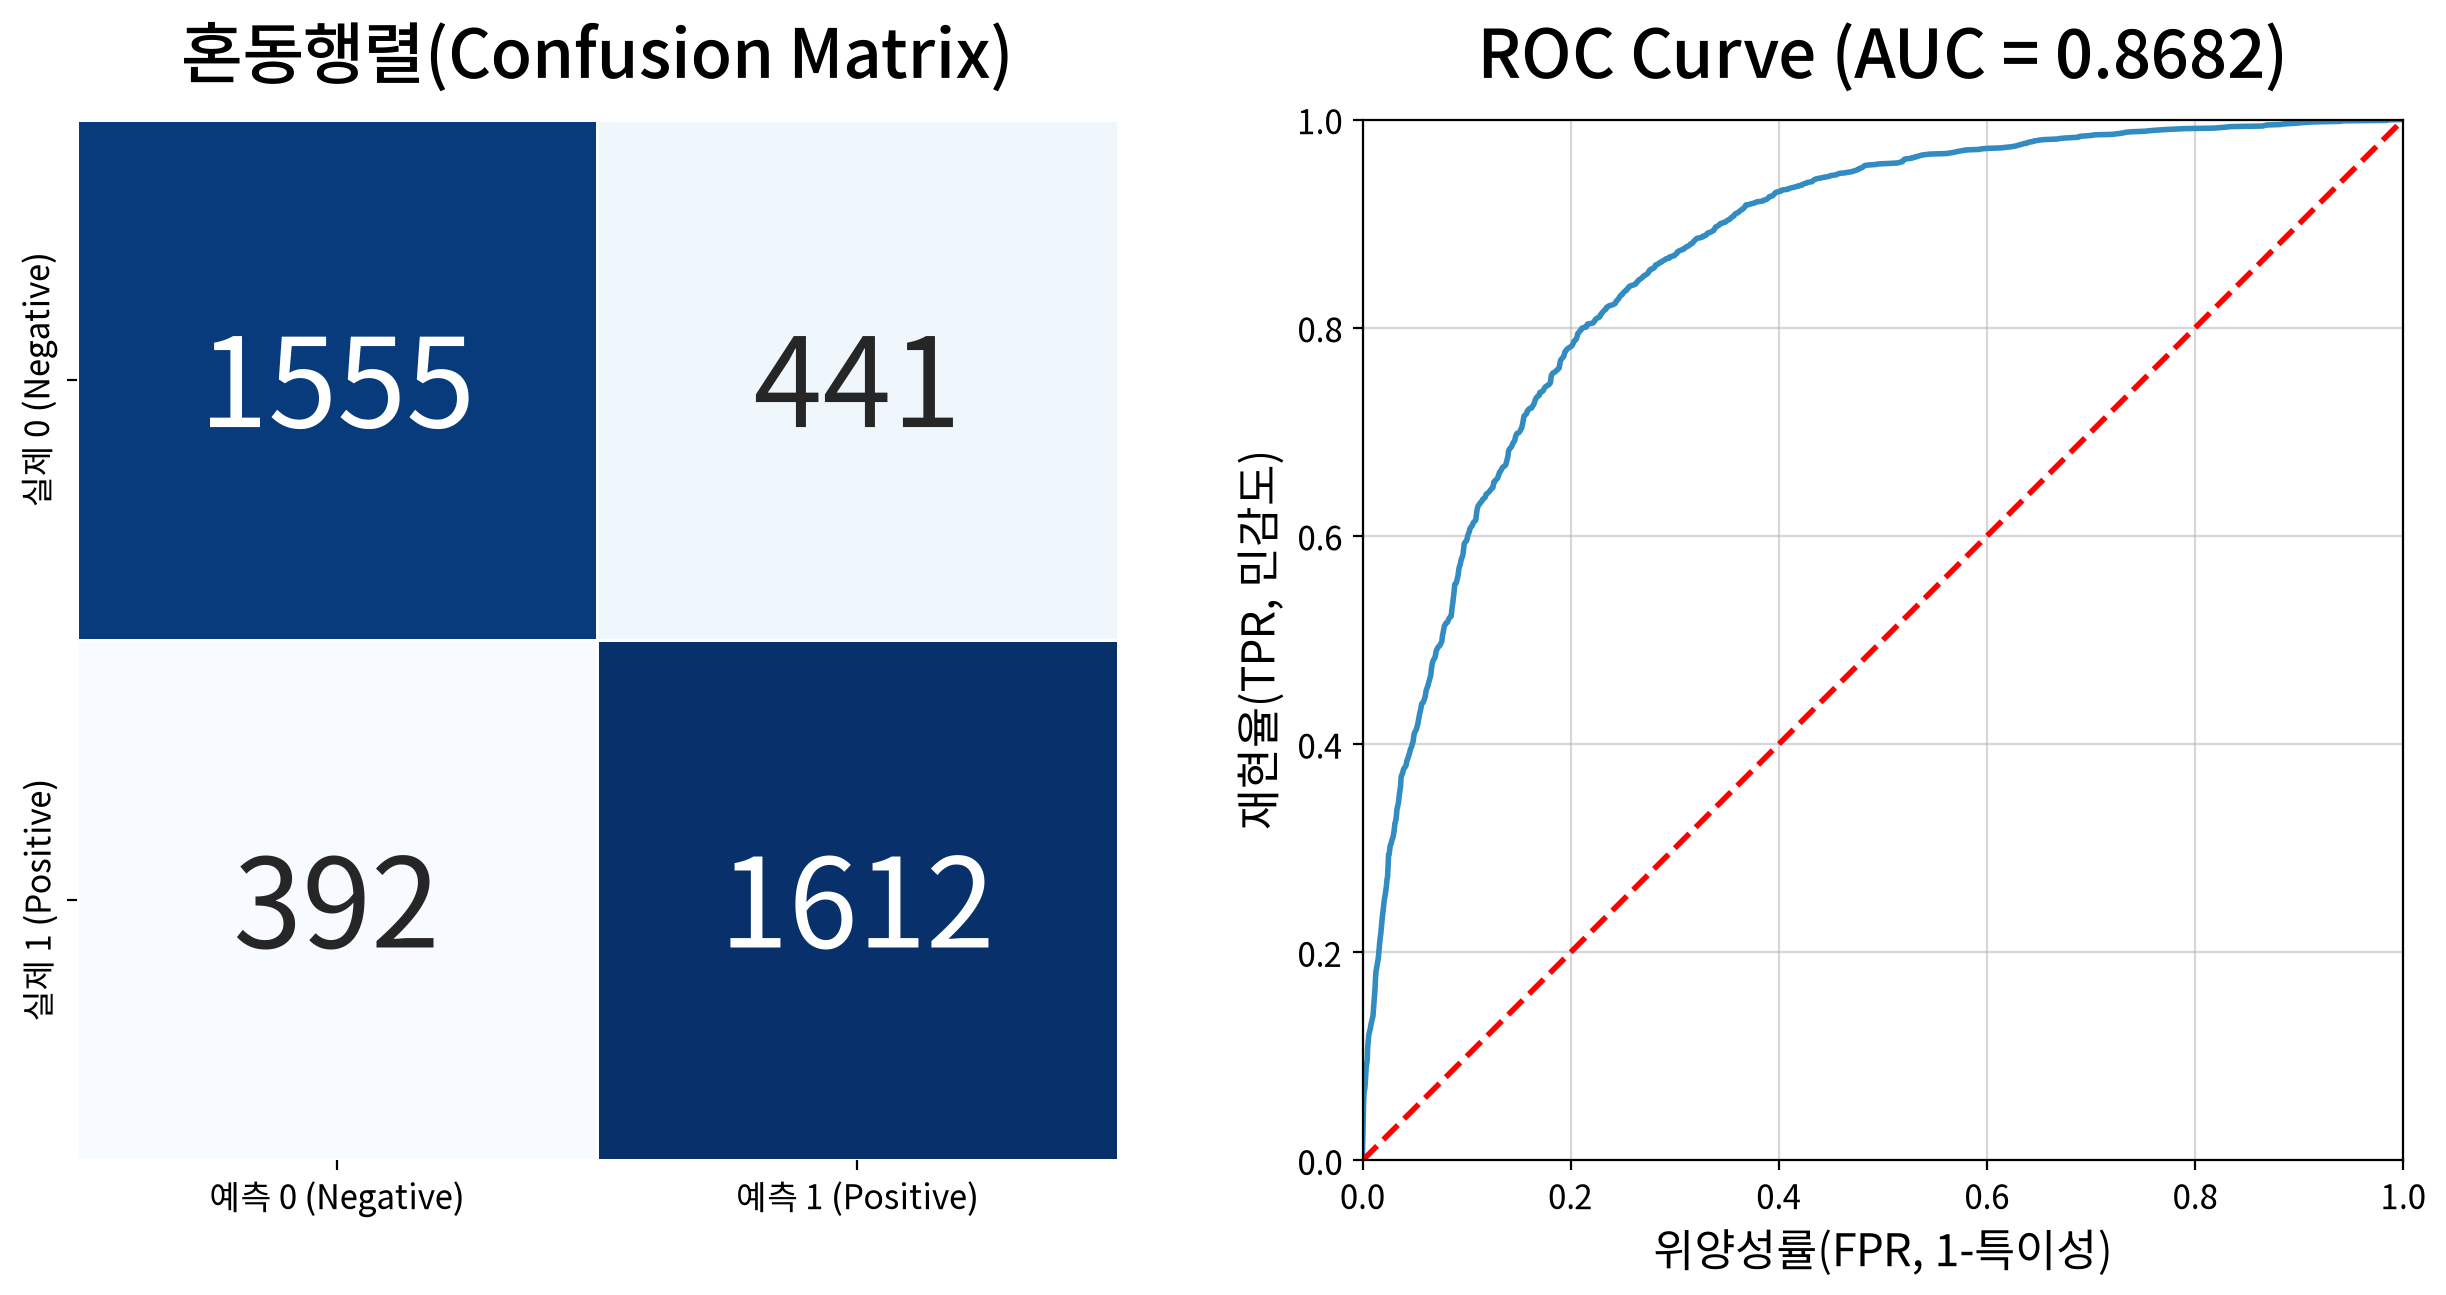

In [17]:
my_logit.report_performance(final_fit)

인사이트 

정확도는 0.5에서 최대 0.792 이지만, 
F1은 0.4에서 최대 0.802


트레이드 오프가 그대로 나타난다

정답은 목적이 정한다. 

### 5. 임계값 조정 
임계값 0.5는 관례일 뿐 정답이 아니다. 목적에 따라 조정한다. 

In [18]:
my_logit.report_threshold(final_fit)

,정확도,정밀도,재현율,F1,놓친 1(FN),잘못 잡은 0 (FP)
임계값,,,,,,
0.300,0.765,0.699,0.932,0.799,137,803
0.400,0.784,0.740,0.875,0.802,250,615
0.500,0.792,0.785,0.804,0.795,392,441
0.600,0.779,0.822,0.713,0.764,575,309
0.700,0.747,0.857,0.594,0.702,813,198


인사이트 

정확도는 0.5에서 최대 0.792 이지만, F1은 0.4에서 최대 0.802 이다.\
트레이드오프가 그대로 나타난다.
임계값 0.3 -> 재현율 0.932 / 정밀도 0.699/ 임계값 0.7-> 정밀도 0.857/ 재현율 0.594

정답은 목적이 정한다.
프리미엄 등급 선별(내보내는 사과는 반드시 good이어야 함 ) -> 임계값을 높여 정밀도 확보 \
폐기 대상 걸러내기(좋은 사과를 버리면 손해) -> 임계값을 낮춰 재현율 확보

한계점 

처방을 고르는 절차가 자동 규칙에 의존한다 

제곱항을 6개 추가하면서 모형이 복잡해졌다

성능을 학습 데이터에서 그래도 측정했다 

변수의 물리적 의미를 알 수 없다 

품질 라벨의 기준이 공개되어 있지 않다 

인과관계가 아니라 연관관계다 

□ 결과 보고 내용을 확인하고 다음 물음에 답하시오.

43. 최종 채택 모델의 독립변수는 몇 개인가요? (정수 1개)

13

44. 모형 적합도 보고에 제시된 Pseudo R²는 얼마인가요? (소수 셋째 자리)

0.342

45. 13개 독립변수 중 유의수준 5% 기준으로 유의하지 않은 것은 무엇인가요? (변수명 1개)

Crunchiness_c

46. 최종 모형에서 표준화 계수(βstd)가 가장 큰 변수는 무엇인가요? (변수명 1개)

Size_c

47. T검정에서 p = 0.985로 완전 무관, 기준선 모형에서도 p = 0.253으로 제거 후보였다가, 제곱항을 넣자 z = 10.40으로 강력한 예측 변수가 된 변수는 무엇인가요? (변수명 1개)

Crunchiness 

48. 최종 모형의 분류 정확도는 얼마인가요? (소수 셋째 자리)

0.792

49. 진단 오즈비(DOR)는 얼마인가요? (소수 첫째 자리)

14.500

50. 혼동행렬에서, 실제로는 good인데 모형이 bad로 잘못 판정해 놓친 사과는 몇 개인가요? (정수 1개)

TF
392

51. 임계값을 0.3 ~ 0.7로 바꿔가며 비교했을 때, F1이 가장 높아지는 임계값은 얼마인가요? (소수 첫째 자리)

0.4

52. 내보내는 사과가 반드시 good이어야 하는 프리미엄 등급 선별에서는 임계값을 높입니다. 이때 확보하려는 지표는 무엇인가요? (지표 이름 1개)

정밀도

53. 훈련·검증 데이터를 나누지 않고 학습 데이터에서 그대로 성능을 측정했습니다. 제곱항 6개를 추가하면서 함께 커진 위험은 무엇인가요? (용어 1개)

과적합 위험 

54. "산도가 낮을수록 good이다"라는 결과를 두고 "산도를 인위적으로 낮추면 사과가 좋아진다"고 말할 수는 없습니다. 이 분석이 밝힌 것은 인과관계가 아니라 무엇인가요? (용어 1개)

연관관계 